In [1]:
import pickle
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, r2_score


Dataset = 'HUST'

filename = f"processed_battery_features_v2_{Dataset}.pkl"

with open(filename, "rb") as f:
    feature_df = pickle.load(f)

feature_df = feature_df.dropna().copy()

In [2]:
# Grid Search Funktion für Random Forest Regressor

def run_rf_gridsearch(
    df,
    feature_columns,
    target_column="SOH"
):

    data = df[feature_columns + [target_column]].dropna()

    X = data[feature_columns]
    y = data[target_column]

    # Train/Test Split
    split_idx = int(len(data) * 0.8)

    X_train = X.iloc[:split_idx]
    X_test = X.iloc[split_idx:]

    y_train = y.iloc[:split_idx]
    y_test = y.iloc[split_idx:]

    # Cross Validation
    tscv = TimeSeriesSplit(n_splits=5)

    rf = RandomForestRegressor(
        random_state=42,
        n_jobs=-1
    )

    param_grid = {
        "n_estimators": [100, 200, 500],
        "max_depth": [None, 10, 20],
        "min_samples_split": [2, 5],
        "min_samples_leaf": [1, 2],
        "max_features": ["sqrt", 0.8]
    }

    grid = GridSearchCV(
        estimator=rf,
        param_grid=param_grid,
        cv=tscv,
        scoring="neg_mean_absolute_error",
        n_jobs=-1,
        verbose=0
    )

    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_

    pred = best_model.predict(X_test)

    return {
        "MAE": mean_absolute_error(y_test, pred),
        "R2": r2_score(y_test, pred),
        "best_params": grid.best_params_,
        "best_model": best_model
    }

In [3]:
feature_groups = {

    # Nur DTW
    "dtw_only": [
        "DTW_V"
    ],

    # Einfache Kurvenabstände
    "curve_distance": [
        "RMSE_V",
        "AreaDiff_V",
        "Corr_V",
        "MaxDev_V",
        "SlopeRMSE_V"
    ],

    # Voltage-Features ohne DTW
    "voltage_simple": [
        "V_curvature",
        "V_std",
        "V_mean",
        "RMSE_V",
        "AreaDiff_V",
        "Corr_V",
        "SlopeRMSE_V"
    ],

    # Bisheriges Voltage-Core Set
    "voltage_core": [
        "DTW_V",
        "V_curvature",
        "V_std",
        "V_mean"
    ],

    # Nur Zeitinformationen
    "time_only": [
        "charge_duration",
        "discharge_duration"
    ],

    # Nur Strominformationen
    "current_only": [
        "I_mean",
        "I_std",
        "DTW_I"
    ],

    # Voltage ohne Zeit
    "voltage_all": [
        "DTW_V",
        "V_curvature",
        "V_std",
        "V_mean",
        "RMSE_V",
        "AreaDiff_V",
        "Corr_V",
        "MaxDev_V",
        "SlopeRMSE_V"
    ],

    # Voltage + Zeit
    "voltage+time": [
        "DTW_V",
        "V_curvature",
        "V_std",
        "V_mean",
        "RMSE_V",
        "AreaDiff_V",
        "Corr_V",
        "MaxDev_V",
        "SlopeRMSE_V",
        "charge_duration",
        "discharge_duration"
    ],

    # Alles
    "full": [
        "DTW_V",
        "DTW_I",

        "V_curvature",
        "V_std",
        "V_mean",
        "V_range",
        "V_slope_mean",
        "V_n_peaks",

        "RMSE_V",
        "AreaDiff_V",
        "Corr_V",
        "MaxDev_V",
        "SlopeRMSE_V",

        "I_mean",
        "I_std",

        "charge_duration",
        "discharge_duration"
    ]
}

In [4]:
results = []
best_models = {}

for name, features in feature_groups.items():

    print(f"Running {name} ...")

    result = run_rf_gridsearch(
        feature_df,
        features
    )

    best_models[name] = result["best_model"]

    results.append({
        "model": name,
        "MAE": result["MAE"],
        "R2": result["R2"],
        "best_params": str(result["best_params"])
    })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="R2",
    ascending=False
)

print(results_df)

Running dtw_only ...
Running curve_distance ...
Running voltage_simple ...
Running voltage_core ...
Running time_only ...
Running current_only ...
Running voltage_all ...
Running voltage+time ...
Running full ...
            model       MAE        R2  \
8            full  0.005458  0.986455   
6     voltage_all  0.008150  0.966987   
7    voltage+time  0.007883  0.966281   
1  curve_distance  0.010847  0.945676   
2  voltage_simple  0.014470  0.916488   
3    voltage_core  0.020226  0.863126   
4       time_only  0.033260  0.622521   
0        dtw_only  0.036877  0.593931   
5    current_only  0.040545  0.432468   

                                         best_params  
8  {'max_depth': None, 'max_features': 0.8, 'min_...  
6  {'max_depth': None, 'max_features': 0.8, 'min_...  
7  {'max_depth': 20, 'max_features': 0.8, 'min_sa...  
1  {'max_depth': 20, 'max_features': 0.8, 'min_sa...  
2  {'max_depth': 20, 'max_features': 0.8, 'min_sa...  
3  {'max_depth': 10, 'max_features': 'sqrt', '

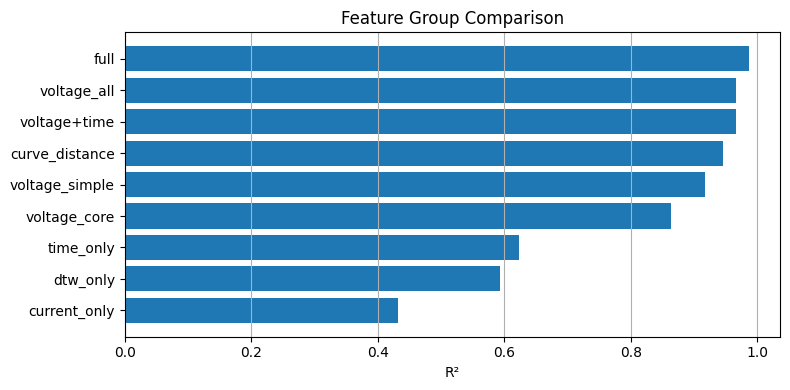

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))

plt.barh(
    results_df["model"],
    results_df["R2"]
)

plt.xlabel("R²")
plt.title("Feature Group Comparison")

plt.grid(axis="x")

plt.gca().invert_yaxis()

# Save figure
plt.tight_layout()
plt.savefig(
    f"figures/feature_group_comparison_{Dataset}.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [7]:
voltage_features = [
    "DTW_V",
    "RMSE_V",
    "AreaDiff_V",
    "Corr_V",
    "MaxDev_V",
    "SlopeRMSE_V",
    "V_curvature",
    "V_std",
    "V_mean"
]

feature_df[voltage_features].corr()

,DTW_V,RMSE_V,AreaDiff_V,Corr_V,MaxDev_V,SlopeRMSE_V,V_curvature,V_std,V_mean
DTW_V,1.000000,0.614396,0.663468,-0.555929,0.597494,0.422460,0.356830,0.469950,0.008577
RMSE_V,0.614396,1.000000,0.977275,-0.935327,0.803476,0.785433,0.738649,0.737695,-0.239017
AreaDiff_V,0.663468,0.977275,1.000000,-0.952956,0.732463,0.741315,0.756554,0.724102,-0.278695
Corr_V,-0.555929,-0.935327,-0.952956,1.000000,-0.680904,-0.693198,-0.772755,-0.620531,0.324289
MaxDev_V,0.597494,0.803476,0.732463,-0.680904,1.000000,0.681112,0.425138,0.463964,-0.032068
SlopeRMSE_V,0.422460,0.785433,0.741315,-0.693198,0.681112,1.000000,0.787702,0.655394,-0.225351
V_curvature,0.356830,0.738649,0.756554,-0.772755,0.425138,0.787702,1.000000,0.714142,-0.193530
V_std,0.469950,0.737695,0.724102,-0.620531,0.463964,0.655394,0.714142,1.000000,0.014601
V_mean,0.008577,-0.239017,-0.278695,0.324289,-0.032068,-0.225351,-0.193530,0.014601,1.000000


In [8]:
from sklearn.inspection import permutation_importance

def permutation_report(model_name):

    features_used = feature_groups[model_name]

    data = feature_df[features_used + ["SOH"]].dropna()

    X = data[features_used]
    y = data["SOH"]

    split_idx = int(len(data) * 0.8)

    X_test = X.iloc[split_idx:]
    y_test = y.iloc[split_idx:]

    result = permutation_importance(
        best_models[model_name],
        X_test,
        y_test,
        n_repeats=20,
        random_state=42,
        n_jobs=-1
    )

    importance_df = pd.DataFrame({
        "feature": X.columns,
        "importance": result.importances_mean,
        "std": result.importances_std
    }).sort_values(
        "importance",
        ascending=False
    )

    return importance_df

In [9]:
permutation_report("time_only")

,feature,importance,std
0,charge_duration,1.633005,0.050063
1,discharge_duration,-0.025710,0.008774


In [10]:
permutation_report("voltage+time")

,feature,importance,std
5,AreaDiff_V,0.476472,0.011367
0,DTW_V,0.101859,0.005352
7,MaxDev_V,0.090328,0.003170
9,charge_duration,0.028327,0.001327
2,V_std,0.024125,0.001781
4,RMSE_V,0.016117,0.000644
6,Corr_V,0.012180,0.000532
10,discharge_duration,0.003511,0.001009
1,V_curvature,0.002694,0.000464
8,SlopeRMSE_V,0.001853,0.000433


In [11]:
permutation_report("full")

,feature,importance,std
9,AreaDiff_V,0.913947,0.021263
11,MaxDev_V,0.108548,0.003284
1,DTW_I,0.068783,0.002838
0,DTW_V,0.043624,0.001971
15,charge_duration,0.038409,0.001621
10,Corr_V,0.021356,0.000716
14,I_std,0.018784,0.000942
8,RMSE_V,0.016798,0.000467
12,SlopeRMSE_V,0.002362,0.000087
3,V_std,0.002326,0.000183


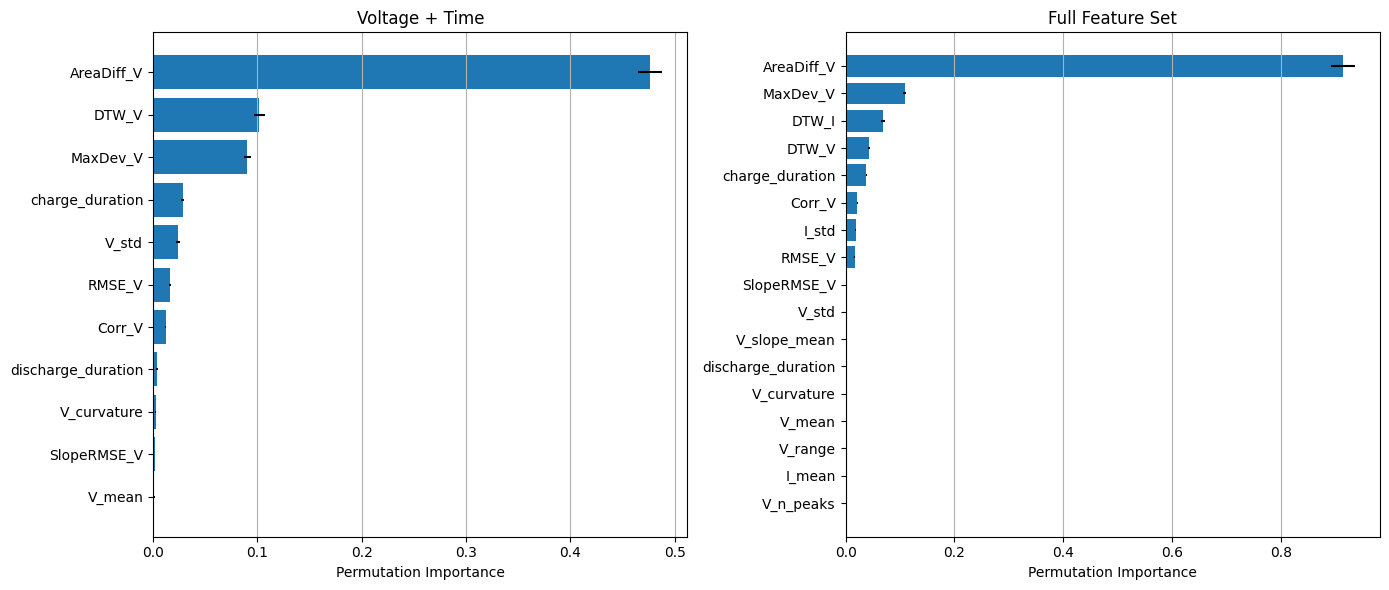

In [12]:
perm_vt = permutation_report("voltage+time")
perm_full = permutation_report("full")

perm_vt = perm_vt.sort_values("importance", ascending=True)
perm_full = perm_full.sort_values("importance", ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].barh(
    perm_vt["feature"],
    perm_vt["importance"],
    xerr=perm_vt["std"]
)
axes[0].set_title("Voltage + Time")
axes[0].set_xlabel("Permutation Importance")
axes[0].grid(axis="x")

axes[1].barh(
    perm_full["feature"],
    perm_full["importance"],
    xerr=perm_full["std"]
)
axes[1].set_title("Full Feature Set")
axes[1].set_xlabel("Permutation Importance")
axes[1].grid(axis="x")

plt.tight_layout()

# Save figure
plt.tight_layout()
plt.savefig(
    f"figures/permutation_report_vtime_full_{Dataset}.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()